# 🤲 Sensi v6 — Modèle 21 classes SANS POSE (mains + visage uniquement)

Idée JC : enlever la pose du corps (qui dépend des vêtements, distance, posture) pour ne garder que ce qui caractérise vraiment le signe — les mains et le visage.

## Features
- AVANT : 282 features (pose 132 + visage 24 + main G 63 + main D 63)
- MAINTENANT : 150 features (visage 24 + main G 63 + main D 63)

**Avantage attendu** : robustesse aux changements de conditions (vêtements, lumière sur le corps, distance).

**Run All** pour tout faire. ~30 min.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f'TensorFlow : {tf.__version__}')

TensorFlow : 2.16.2


## 2. Configuration

In [2]:
DATA_DIR = Path('/Users/jean-christophebertincourt/Desktop/Prise mouvement')

MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

# 21 classes complètes
my_signes = {
    'mouvement_1':  'aider',
    'mouvement_2':  'ameliorer',
    'mouvement_3':  'ami',
    'mouvement_4':  "aujourd'hui",
    'mouvement_5':  'bonjour',
    'mouvement_6':  'communiquer',
    'mouvement_7':  'entendant',
    'mouvement_8':  'content',
    'mouvement_9':  'je_suis',
    'mouvement_10': 'je_veux',
    'mouvement_11': 'langue_des_signes',
    'mouvement_12': 'merci',
    'mouvement_13': 'outil_pointage',
    'mouvement_14': 'outil',
    'mouvement_15': 'presenter',
    'mouvement_16': 'projet',
    'mouvement_17': 'sourd_pointage',
    'mouvement_18': 'sourde',
    'mouvement_19': 'traduction',
    'mouvement_20': 'vocal',
    'mouvement_21': 'inconnu',
}

signs_list = list(my_signes.values())
sign_to_idx = {sign: i for i, sign in enumerate(signs_list)}
idx_to_sign = {i: sign for sign, i in sign_to_idx.items()}

n_classes = len(my_signes)

# Format des features dans les .npy actuels :
# Pose      : indices 0   à 131  (132 = 33 landmarks x 4)
# Visage    : indices 132 à 155  (24 = 8 landmarks x 3)
# Main G    : indices 156 à 218  (63 = 21 landmarks x 3)
# Main D    : indices 219 à 281  (63 = 21 landmarks x 3)

POSE_END = 132    # début du visage
# On veut tout SAUF la pose -> on prend des indices 132 à 281 = 150 features

N_FEATURES_SANS_POSE = 282 - POSE_END

print(f'DATA_DIR existe : {DATA_DIR.exists()}')
print(f'Nombre de classes : {n_classes}')
print(f'Features sans pose : {N_FEATURES_SANS_POSE} (au lieu de 282)')

DATA_DIR existe : True
Nombre de classes : 21
Features sans pose : 150 (au lieu de 282)


## 3. Chargement + filtrage des features

On lit les `.npy` à 282 features et on garde **uniquement les colonnes 132 à 281** (visage + mains, pas la pose).

In [3]:
X_list = []
y_list = []

for mouvement_name, sign_name in tqdm(my_signes.items(), desc='Chargement'):
    label = sign_to_idx[sign_name]
    folder = DATA_DIR / mouvement_name
    
    if not folder.exists():
        print(f'⚠️ Dossier manquant : {folder}')
        continue
    
    for npy_file in folder.glob('*.npy'):
        data = np.load(npy_file).astype(np.float32)
        # On garde SEULEMENT visage + mains (drop pose)
        data_no_pose = data[:, POSE_END:]
        X_list.append(data_no_pose)
        y_list.append(label)

X = np.array(X_list)
y = np.array(y_list)

print(f'\nShape de X : {X.shape}')
print(f'(60 frames, {X.shape[2]} features sans pose)')
print(f'Classes : {np.unique(y)}')

counts = Counter(y)
print('\nRépartition :')
for i in range(n_classes):
    n = counts.get(i, 0)
    bar = '█' * n
    print(f'  {i:2d}  {idx_to_sign[i]:20s} : {n:3d}  {bar}')
print(f'\nTotal : {len(y)}')

Chargement: 100%|███████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 65.88it/s]


Shape de X : (930, 60, 150)
(60 frames, 150 features sans pose)
Classes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Répartition :
   0  aider                :  45  █████████████████████████████████████████████
   1  ameliorer            :  45  █████████████████████████████████████████████
   2  ami                  :  45  █████████████████████████████████████████████
   3  aujourd'hui          :  45  █████████████████████████████████████████████
   4  bonjour              :  45  █████████████████████████████████████████████
   5  communiquer          :  45  █████████████████████████████████████████████
   6  entendant            :  45  █████████████████████████████████████████████
   7  content              :  45  █████████████████████████████████████████████
   8  je_suis              :  45  █████████████████████████████████████████████
   9  je_veux              :  45  █████████████████████████████████████████████
  10  langue_des_signes    :  45  ███████████

## 4. Split + augmentation

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')

X_train : (744, 60, 150)
X_val   : (186, 60, 150)


In [5]:
def augment_sequence(seq):
    """3 augmentations : jitter, vitesse, décalage léger."""
    seq = seq.copy()
    
    # 1. Jitter
    noise = np.random.normal(0, 0.01, seq.shape).astype(np.float32)
    seq = seq + noise
    
    # 2. Variation de vitesse
    if np.random.random() < 0.5:
        speed_factor = np.random.uniform(0.85, 1.15)
        n_target = int(seq.shape[0] * speed_factor)
        indices = np.linspace(0, seq.shape[0] - 1, n_target).astype(int)
        seq = seq[indices]
        if seq.shape[0] >= 60:
            seq = seq[:60]
        else:
            pad = np.zeros((60 - seq.shape[0], seq.shape[1]), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=0)
    
    # 3. Décalage temporel léger
    if np.random.random() < 0.4:
        shift = np.random.randint(-3, 4)
        if shift > 0:
            seq = np.concatenate([np.zeros((shift, seq.shape[1]), dtype=np.float32), seq[:-shift]], axis=0)
        elif shift < 0:
            seq = np.concatenate([seq[-shift:], np.zeros((-shift, seq.shape[1]), dtype=np.float32)], axis=0)
    
    if seq.shape[0] != 60:
        if seq.shape[0] > 60:
            seq = seq[:60]
        else:
            pad = np.zeros((60 - seq.shape[0], seq.shape[1]), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=0)
    
    return seq.astype(np.float32)


print('Génération des données augmentées (x3)...')
X_train_augmented = [X_train]
y_train_augmented = [y_train]
for pass_num in range(2):
    X_aug = np.array([augment_sequence(x) for x in X_train], dtype=np.float32)
    X_train_augmented.append(X_aug)
    y_train_augmented.append(y_train)
    print(f'  Pass {pass_num + 1} : +{len(X_aug)}')
X_train_aug = np.concatenate(X_train_augmented, axis=0)
y_train_aug = np.concatenate(y_train_augmented, axis=0)
print(f'\nDataset augmenté : {X_train_aug.shape}')

Génération des données augmentées (x3)...
  Pass 1 : +744
  Pass 2 : +744

Dataset augmenté : (2232, 60, 150)


## 5. Modèle (input adapté à 150 features)

In [6]:
model_v6 = Sequential([
    Input(shape=(60, N_FEATURES_SANS_POSE)),
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(n_classes, activation='softmax'),
])

model_v6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_v6.summary()

2026-06-04 17:55:37.005049: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-06-04 17:55:37.005084: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-06-04 17:55:37.005087: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-06-04 17:55:37.005108: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 17:55:37.005118: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       110,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │           693 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,541 (451.33 KB)

 Trainable params: 115,221 (450.08 KB)

 Non-trainable params: 320 (1.25 KB)

## 6. Entraînement

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5, verbose=1),
]

history_v6 = model_v6.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100


2026-06-04 17:55:37.818652: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.0869 - loss: 3.4883 - val_accuracy: 0.1075 - val_loss: 2.8961 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1174 - loss: 3.0802 - val_accuracy: 0.2258 - val_loss: 2.7674 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1411 - loss: 2.8703 - val_accuracy: 0.1559 - val_loss: 2.6665 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1832 - loss: 2.6686 - val_accuracy: 0.2151 - val_loss: 2.5176 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2312 - loss: 2.4967 - val_accuracy: 0.3118 - val_loss: 2.3332 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2392 - loss: 2.3819 - val_accuracy: 0.2849 - val_loss: 2.2669 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2715 - loss: 2.2560 - val_accuracy

## 7. Courbes + sauvegarde

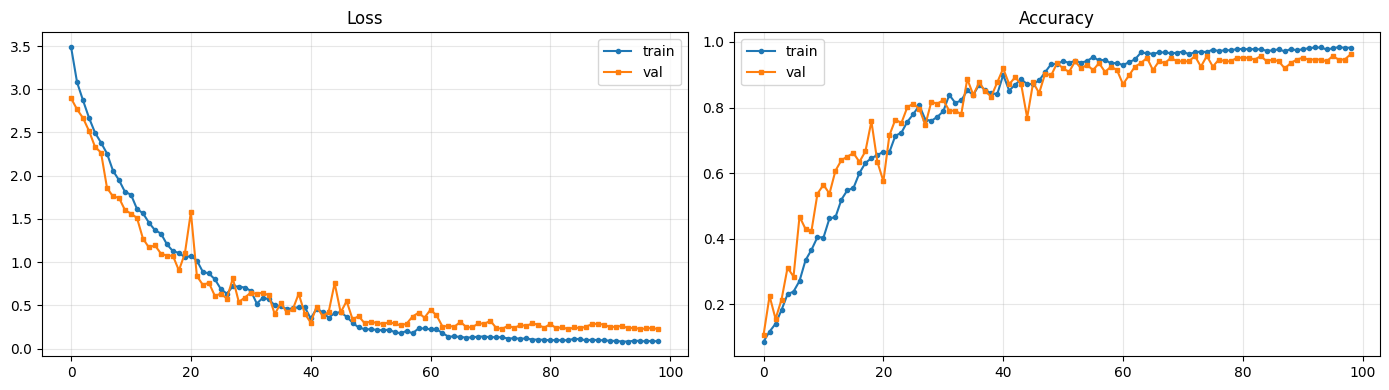


📊 Best val_accuracy : 96.24%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_v6.history['loss'], label='train', marker='o', markersize=3)
axes[0].plot(history_v6.history['val_loss'], label='val', marker='s', markersize=3)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_v6.history['accuracy'], label='train', marker='o', markersize=3)
axes[1].plot(history_v6.history['val_accuracy'], label='val', marker='s', markersize=3)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best_val = max(history_v6.history['val_accuracy'])
print(f'\n📊 Best val_accuracy : {best_val:.2%}')

In [11]:
model_v6.save(MODEL_DIR / 'sensi_team_v6.keras')

metadata = {
    'mouvement_to_sign': my_signes,
    'sign_to_idx': sign_to_idx,
    'idx_to_sign': {str(k): v for k, v in idx_to_sign.items()},
    'n_classes': n_classes,
    'n_frames': 60,
    'n_features': N_FEATURES_SANS_POSE,
    'features_kept': 'visage + main gauche + main droite (PAS de pose)',
    'best_val_accuracy': float(best_val),
    'notes': '21 classes SANS POSE pour robustesse aux variations de vetements/distance/posture',
}
with open(MODEL_DIR / 'sensi_team_v6_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'✅ Modèle v6 sauvegardé')
print(f'📊 Val accuracy : {best_val:.2%}')
print(f'\nPath : {(MODEL_DIR / "sensi_team_v6.keras").absolute()}')

✅ Modèle v6 sauvegardé
📊 Val accuracy : 96.24%

Path : /Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/models/sensi_team_v6.keras


## 8. Matrice de confusion

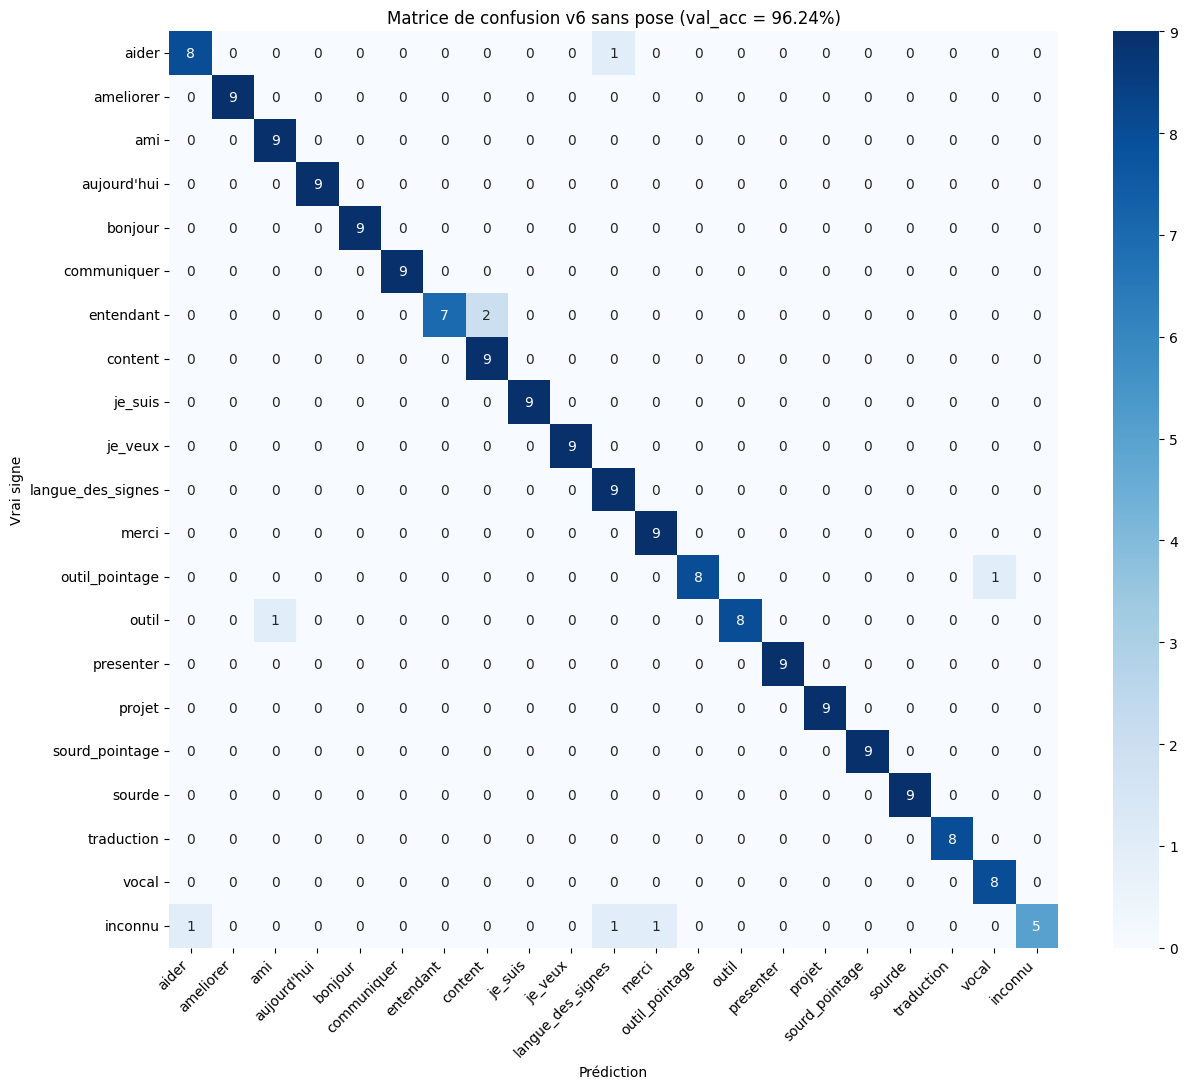

                   precision    recall  f1-score   support

            aider       0.89      0.89      0.89         9
        ameliorer       1.00      1.00      1.00         9
              ami       0.90      1.00      0.95         9
      aujourd'hui       1.00      1.00      1.00         9
          bonjour       1.00      1.00      1.00         9
      communiquer       1.00      1.00      1.00         9
        entendant       1.00      0.78      0.88         9
          content       0.82      1.00      0.90         9
          je_suis       1.00      1.00      1.00         9
          je_veux       1.00      1.00      1.00         9
langue_des_signes       0.82      1.00      0.90         9
            merci       0.90      1.00      0.95         9
   outil_pointage       1.00      0.89      0.94         9
            outil       1.00      0.89      0.94         9
        presenter       1.00      1.00      1.00         9
           projet       1.00      1.00      1.00       

In [10]:
y_pred = model_v6.predict(X_val, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_val, y_pred, labels=list(range(n_classes)))

plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_sign[i] for i in range(n_classes)],
            yticklabels=[idx_to_sign[i] for i in range(n_classes)])
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.xlabel('Prédiction'); plt.ylabel('Vrai signe')
plt.title(f'Matrice de confusion v6 sans pose (val_acc = {best_val:.2%})')
plt.tight_layout(); plt.show()

print(classification_report(y_val, y_pred,
      target_names=[idx_to_sign[i] for i in range(n_classes)], zero_division=0))

## ✅ Modèle prêt

Le modèle est dans `models/sensi_team_v6.keras` avec ses métadonnées.

**IMPORTANT** : il faut un script live adapté qui extrait aussi **150 features sans la pose**.
Demande-le maintenant si pas encore livré.